<a href="https://colab.research.google.com/github/aathil28/CDC_Diabetes_Health_Indicators_Preprocessing_Dataset/blob/feature%2Fdata_transforming/CDC_Diabetes_Preprocessing_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Clone Git Repo
# ***************
!git clone ''

# Libraries

##Loading Libraries

In [37]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import MinMaxScaler



# Reading data

In [5]:
# Mounting Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# Reading Dataset
filepath = '/content/drive/MyDrive/Colab Notebooks/Datasets /diabetes_binary_health_indicators_BRFSS2015[1].csv'
df_cdc = pd.read_csv(filepath)
df_cdc.head(10)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
6,0.0,1.0,0.0,1.0,30.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,3.0,0.0,14.0,0.0,0.0,9.0,6.0,7.0
7,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,0.0,0.0,1.0,0.0,11.0,4.0,4.0
8,1.0,1.0,1.0,1.0,30.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,5.0,1.0
9,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,4.0,3.0


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# EDA (Exploratory Data Analysis)

In [8]:
df_cdc.info()
# This shows
# number of rows
# number of columns
# column names
# how many non-null values each column has
# each column’s data type
# memory usage

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [9]:
df_cdc.describe() # This shows the Values, Ranges, Spread

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [10]:
df_cdc.shape # This shows the size of the DataFrame

(253680, 22)

In [11]:
df_cdc.columns # This shows the names of columns the DataFrame

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [12]:
df_cdc.isna() # This checks for missing values

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
253676,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
253677,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
253678,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [13]:
df_cdc.isna().sum() # This checks sum of missing values in each column

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [14]:
for i in df_cdc.columns: # This means for each columns in df_cdc, 'basically a loop'
  print('Columns :',i)   # This prints the column names
  print(df_cdc[i].unique()) # This prints the unique values in each columns

Columns : Diabetes_binary
[0. 1.]
Columns : HighBP
[1. 0.]
Columns : HighChol
[1. 0.]
Columns : CholCheck
[1. 0.]
Columns : BMI
[40. 25. 28. 27. 24. 30. 34. 26. 33. 21. 23. 22. 38. 32. 37. 31. 29. 20.
 35. 45. 39. 19. 47. 18. 36. 43. 55. 49. 42. 17. 16. 41. 44. 50. 59. 48.
 52. 46. 54. 57. 53. 14. 15. 51. 58. 63. 61. 56. 74. 62. 64. 66. 73. 85.
 60. 67. 65. 70. 82. 79. 92. 68. 72. 88. 96. 13. 81. 71. 75. 12. 77. 69.
 76. 87. 89. 84. 95. 98. 91. 86. 83. 80. 90. 78.]
Columns : Smoker
[1. 0.]
Columns : Stroke
[0. 1.]
Columns : HeartDiseaseorAttack
[0. 1.]
Columns : PhysActivity
[0. 1.]
Columns : Fruits
[0. 1.]
Columns : Veggies
[1. 0.]
Columns : HvyAlcoholConsump
[0. 1.]
Columns : AnyHealthcare
[1. 0.]
Columns : NoDocbcCost
[0. 1.]
Columns : GenHlth
[5. 3. 2. 4. 1.]
Columns : MentHlth
[18.  0. 30.  3.  5. 15. 10.  6. 20.  2. 25.  1.  4.  7.  8. 21. 14. 26.
 29. 16. 28. 11. 12. 24. 17. 13. 27. 19. 22.  9. 23.]
Columns : PhysHlth
[15.  0. 30.  2. 14. 28.  7. 20.  3. 10.  1.  5. 17.  4. 19. 

In [15]:
for i in df_cdc.columns: # This means for each columns in df_cdc, 'basically a loop'
  print('Columns :',i)   # This prints the column names
  print(df_cdc[i].value_counts()) # This prints the values counts in each columns

Columns : Diabetes_binary
Diabetes_binary
0.0    218334
1.0     35346
Name: count, dtype: int64
Columns : HighBP
HighBP
0.0    144851
1.0    108829
Name: count, dtype: int64
Columns : HighChol
HighChol
0.0    146089
1.0    107591
Name: count, dtype: int64
Columns : CholCheck
CholCheck
1.0    244210
0.0      9470
Name: count, dtype: int64
Columns : BMI
BMI
27.0    24606
26.0    20562
24.0    19550
25.0    17146
28.0    16545
        ...  
85.0        1
86.0        1
91.0        1
90.0        1
78.0        1
Name: count, Length: 84, dtype: int64
Columns : Smoker
Smoker
0.0    141257
1.0    112423
Name: count, dtype: int64
Columns : Stroke
Stroke
0.0    243388
1.0     10292
Name: count, dtype: int64
Columns : HeartDiseaseorAttack
HeartDiseaseorAttack
0.0    229787
1.0     23893
Name: count, dtype: int64
Columns : PhysActivity
PhysActivity
1.0    191920
0.0     61760
Name: count, dtype: int64
Columns : Fruits
Fruits
1.0    160898
0.0     92782
Name: count, dtype: int64
Columns : Veggies
Ve

##Histogram

In [16]:
non_cat = ['BMI', 'MentHlth', 'PhysHlth']
non_cat

['BMI', 'MentHlth', 'PhysHlth']

[]

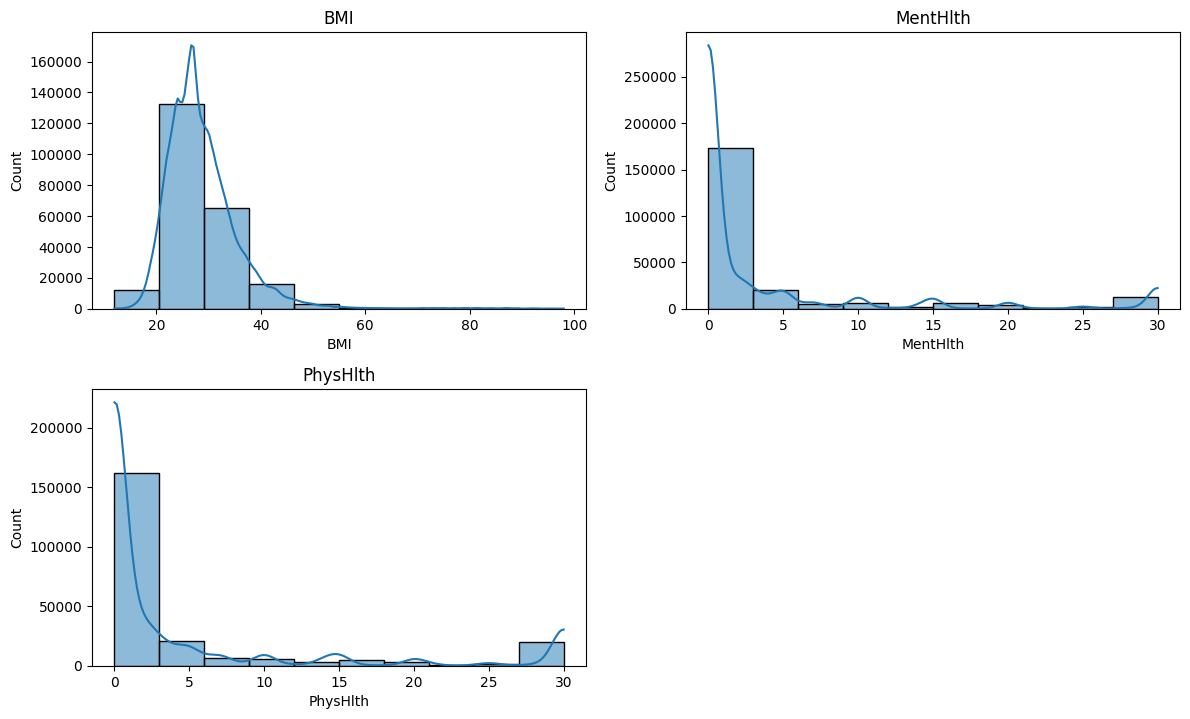

In [33]:
plt.figure(figsize = (12,14))
for i , column in enumerate(non_cat, 1):
  plt.subplot(4,2,i)
  sns.histplot(df_cdc[column], kde = True, bins = 10)
  plt.title(column)
  plt.xlabel(column)
plt.tight_layout()
plt.plot()


In [36]:
# Checking skewness
for col in non_cat:
    print(f"\nColumn: {col}")
    print(df_cdc[col].skew())


Column: BMI
2.063475270647552

Column: MentHlth
2.5445322318683075

Column: PhysHlth
2.044139144084555


In [ ]:
# BMI, MentHlth, and PhysHlth histogram shows they are right skewed

#Preprocessing

##Data Cleaning

###Missing Value analysis

In [38]:
# No missing values in the data set

### Outlier Management

#### Creating boxplots

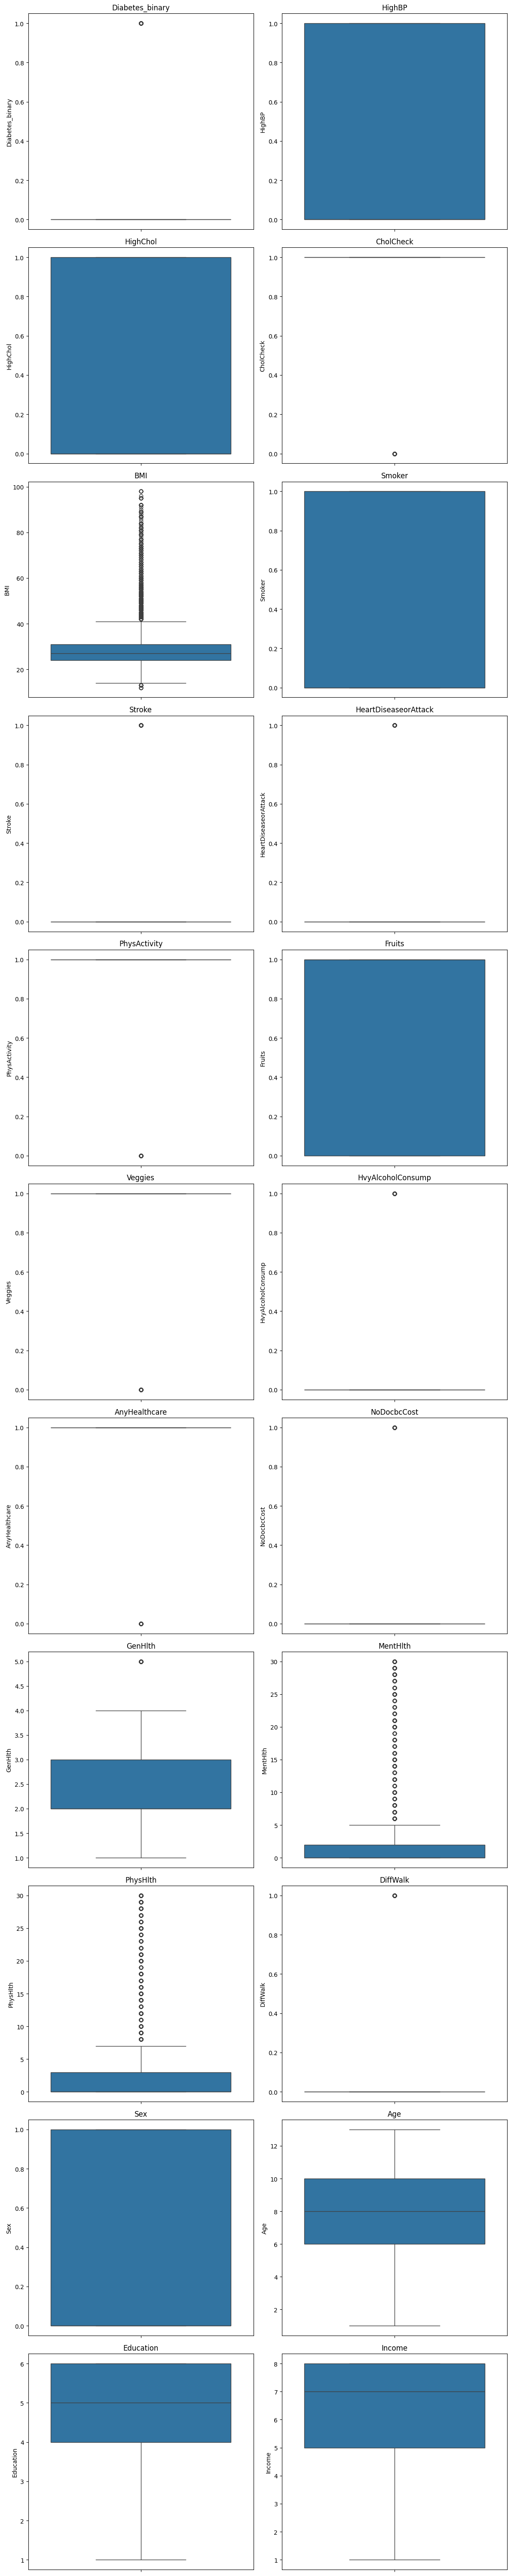

In [18]:
plt.figure(figsize= (12, 60))
i= 1

for column in df_cdc:
  plt.subplot(11,2,i)
  sns.boxplot(df_cdc[column])
  plt.title(column)
  i += 1

plt.tight_layout()
plt.show()

checking the amount of outliers

In [19]:
for column in df_cdc :
  Q1 = df_cdc[column].quantile(0.25)
  Q3 = df_cdc[column].quantile(0.75)

  IQR = Q3- Q1

  lower = Q1 - 1.5*IQR
  upper = Q3 + 1.5*IQR
  Outliers = df_cdc[column][(df_cdc[column]< lower) | (df_cdc[column] > upper)]

  print("Column :", column)
  print("Q1 :",Q1)
  print("Q3 :",Q3)
  print("IQR :",IQR)
  print("Number of outliers:" ,len(Outliers))


Column : Diabetes_binary
Q1 : 0.0
Q3 : 0.0
IQR : 0.0
Number of outliers: 35346
Column : HighBP
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Number of outliers: 0
Column : HighChol
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Number of outliers: 0
Column : CholCheck
Q1 : 1.0
Q3 : 1.0
IQR : 0.0
Number of outliers: 9470
Column : BMI
Q1 : 24.0
Q3 : 31.0
IQR : 7.0
Number of outliers: 9847
Column : Smoker
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Number of outliers: 0
Column : Stroke
Q1 : 0.0
Q3 : 0.0
IQR : 0.0
Number of outliers: 10292
Column : HeartDiseaseorAttack
Q1 : 0.0
Q3 : 0.0
IQR : 0.0
Number of outliers: 23893
Column : PhysActivity
Q1 : 1.0
Q3 : 1.0
IQR : 0.0
Number of outliers: 61760
Column : Fruits
Q1 : 0.0
Q3 : 1.0
IQR : 1.0
Number of outliers: 0
Column : Veggies
Q1 : 1.0
Q3 : 1.0
IQR : 0.0
Number of outliers: 47839
Column : HvyAlcoholConsump
Q1 : 0.0
Q3 : 0.0
IQR : 0.0
Number of outliers: 14256
Column : AnyHealthcare
Q1 : 1.0
Q3 : 1.0
IQR : 0.0
Number of outliers: 12417
Column : NoDocbcCost
Q1 : 0.0
Q3 : 0.0
IQR : 0.0
Number 

No outliers detected by IQR method is removed as IQR method are within the possible range of values.

### Duplicate's Management

In [20]:
df_cdc.duplicated().sum()

np.int64(24206)

In [21]:
# calculating the percentage of duplicate entries

perc_duplicate = ((df_cdc.duplicated().sum())/len(df_cdc))*100
perc_duplicate

#9.420 % of the observations are duplicates. Hence removing it

np.float64(9.541942604856512)

In [22]:
df_cdc.drop_duplicates(inplace =True)
len(df_cdc)

#

229474

###Correlation Analysis

In [23]:
corr_matrix = df_cdc.corr()
corr_matrix

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Diabetes_binary,1.000000,0.254318,0.194944,0.072523,0.205086,0.045504,0.099193,0.168213,-0.100404,-0.024805,...,0.025331,0.020048,0.276940,0.054153,0.156211,0.205302,0.032724,0.177263,-0.102686,-0.140659
HighBP,0.254318,1.000000,0.283963,0.111259,0.194218,0.074264,0.124558,0.201443,-0.104382,-0.019467,...,0.052044,0.002292,0.272784,0.037482,0.144656,0.211759,0.047119,0.339802,-0.112887,-0.140030
HighChol,0.194944,0.283963,1.000000,0.094772,0.089734,0.074583,0.089375,0.176446,-0.063443,-0.026257,...,0.052363,0.003020,0.188139,0.050346,0.111008,0.136045,0.022859,0.263841,-0.050045,-0.062089
CholCheck,0.072523,0.111259,0.094772,1.000000,0.042487,-0.003721,0.027955,0.050086,-0.004555,0.017860,...,0.115498,-0.054128,0.062939,-0.001430,0.040758,0.049107,-0.024332,0.095942,-0.009935,0.001989
BMI,0.205086,0.194218,0.089734,0.042487,1.000000,-0.009294,0.011006,0.039820,-0.127780,-0.067424,...,-0.008519,0.045795,0.208351,0.068569,0.102768,0.182556,0.030902,-0.049223,-0.074433,-0.069097
Smoker,0.045504,0.074264,0.074583,-0.003721,-0.009294,1.000000,0.054414,0.105169,-0.066869,-0.061731,...,-0.013963,0.037335,0.134894,0.077641,0.100447,0.108144,0.096650,0.107695,-0.135657,-0.095314
Stroke,0.099193,0.124558,0.089375,0.027955,0.011006,0.054414,1.000000,0.198814,-0.059306,-0.004486,...,0.013627,0.028613,0.169809,0.061996,0.140806,0.169339,0.003626,0.128209,-0.064178,-0.117108
HeartDiseaseorAttack,0.168213,0.201443,0.176446,0.050086,0.039820,0.105169,0.198814,1.000000,-0.073094,-0.006946,...,0.025987,0.021971,0.246328,0.052601,0.170335,0.202657,0.089828,0.223912,-0.082288,-0.122728
PhysActivity,-0.100404,-0.104382,-0.063443,-0.004555,-0.127780,-0.066869,-0.059306,-0.073094,1.000000,0.125023,...,0.023959,-0.046440,-0.237511,-0.105914,-0.199307,-0.235719,0.033516,-0.087881,0.170931,0.165869
Fruits,-0.024805,-0.019467,-0.026257,0.017860,-0.067424,-0.061731,-0.004486,-0.006946,0.125023,1.000000,...,0.022659,-0.032387,-0.071221,-0.052191,-0.024441,-0.029932,-0.088768,0.073515,0.084857,0.050907


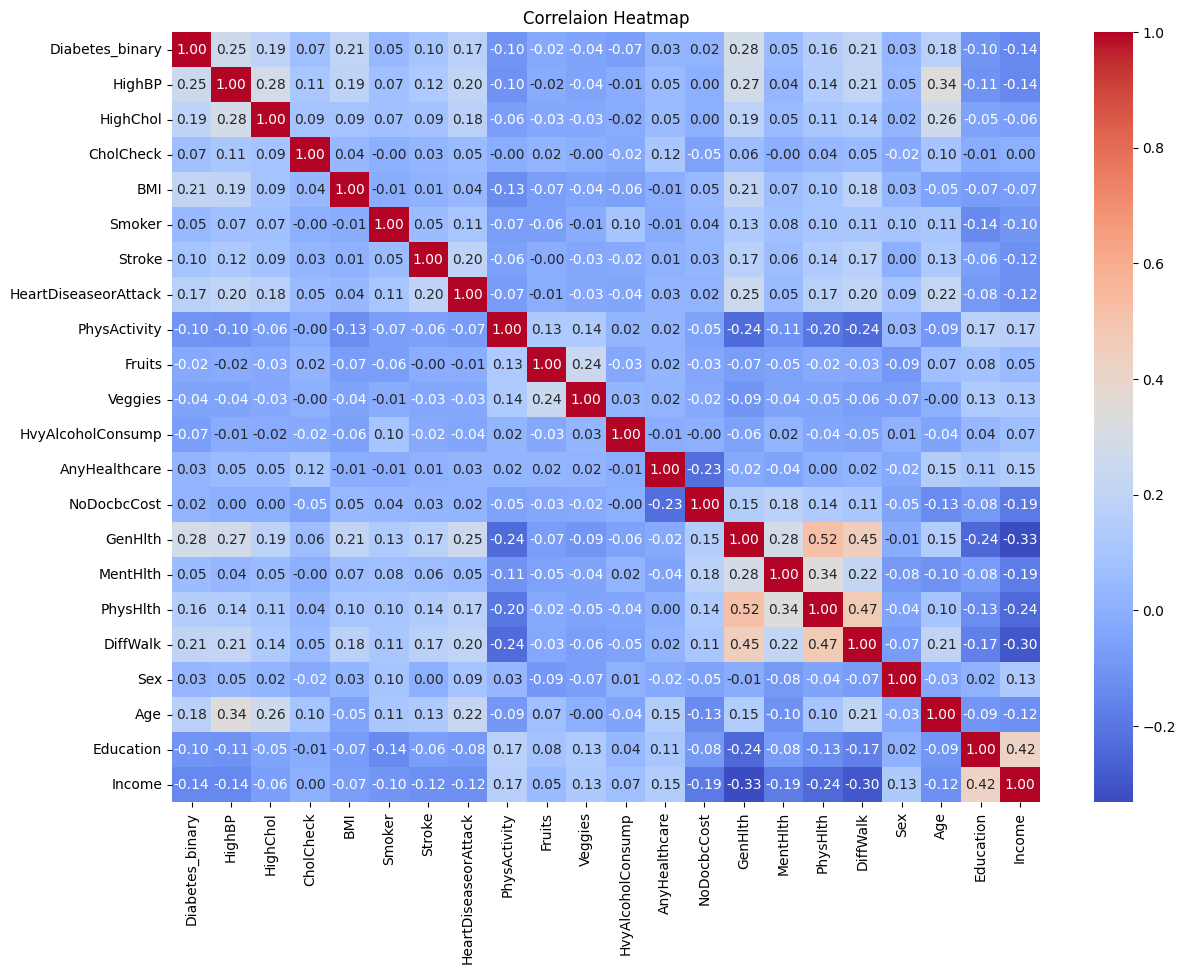

In [24]:
#plotting correlation heatmap
plt.figure(figsize = (14,10)) # width and height of the map
sns.heatmap(corr_matrix,
            annot = True,
            cmap = "coolwarm",
            fmt = ".2f") # display 2 decimal places
plt.title("Correlaion Heatmap")
plt.show()

In [28]:
# correlation of feature wrt target
corr_target = df_cdc.corr()["Diabetes_binary"]
# sort in ascending order
corr_target.sort_values(ascending = True)

,Diabetes_binary
Income,-0.140659
Education,-0.102686
PhysActivity,-0.100404
HvyAlcoholConsump,-0.065950
Veggies,-0.041734
Fruits,-0.024805
NoDocbcCost,0.020048
AnyHealthcare,0.025331
Sex,0.032724
Smoker,0.045504


##Data Transforming

###Scaling

In [41]:
# Before scaling
df_cdc.head(5)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [42]:
# Scaling the continuous numerical column
# For skewed we use MinMaxScaler, since histogram of BHI is right skewed
min_max_scaler = MinMaxScaler()
skew_cols = ['BMI']

df_cdc[skew_cols] = min_max_scaler.fit_transform(df_cdc[skew_cols])

In [43]:
# After scaling
df_cdc.head(5)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,0.325581,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,0.151163,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,0.186047,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,0.174419,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,0.139535,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


###Encoding

In [ ]:
# Inference : No additional encoding was performed because all categorical variables in the dataset were already numerically encoded.

##Mutual Information Analysis

In [31]:
X = df_cdc.drop(columns=["Diabetes_binary"])
y = df_cdc["Diabetes_binary"]
mi = mutual_info_classif(X, y, random_state = 42)
#convert mi into dataframe
mi_df = pd.DataFrame({"Features" : X.columns, "Mutual Information" :mi })
mi_df


,Features,Mutual Information
0,HighBP,0.051681
1,HighChol,0.038154
2,CholCheck,0.046302
3,BMI,0.026834
4,Smoker,0.024940
5,Stroke,0.004186
6,HeartDiseaseorAttack,0.011442
7,PhysActivity,0.042962
8,Fruits,0.034341
9,Veggies,0.038575
